# Introduction

**Objective**

The goal of this project is to analyze Superstore sales data to identify key business insights related to sales, profit, categories, regions, discounts, and time-based trends.

**Main questions**
1. Which categories generate the highest sales and profit?
2. Which sub-categories are the most and least profitable?
3. Which regions perform best?
4. How do discounts affect profit?
5. How did sales and profit change over time?

# Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Kaggle Notebook

# Imports

In [1]:
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None) # To show all the columns

df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv', encoding='latin1')

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


# Data Preparation

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [3]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Year-Month'] = df['Order Date'].dt.to_period('M')

In [4]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Year-Month,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10,7


# Category Analysis

**Which categories generate the highest sales and profit?**

In [6]:
category_summary = df.groupby('Category')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)
category_summary

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


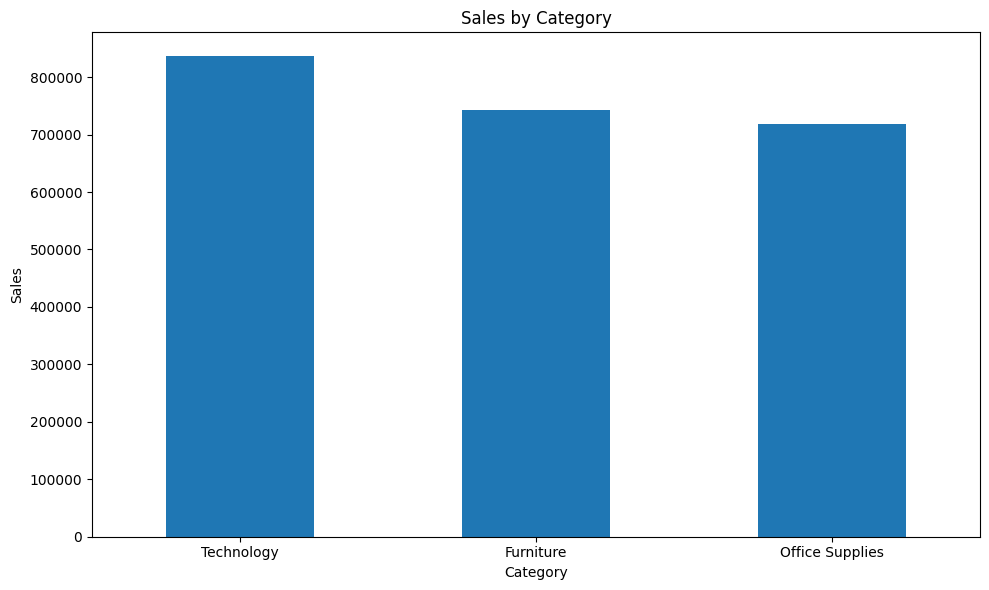

In [7]:
# Chart for Sales
category_summary['Sales'].plot(kind='bar',figsize=(10,6))

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

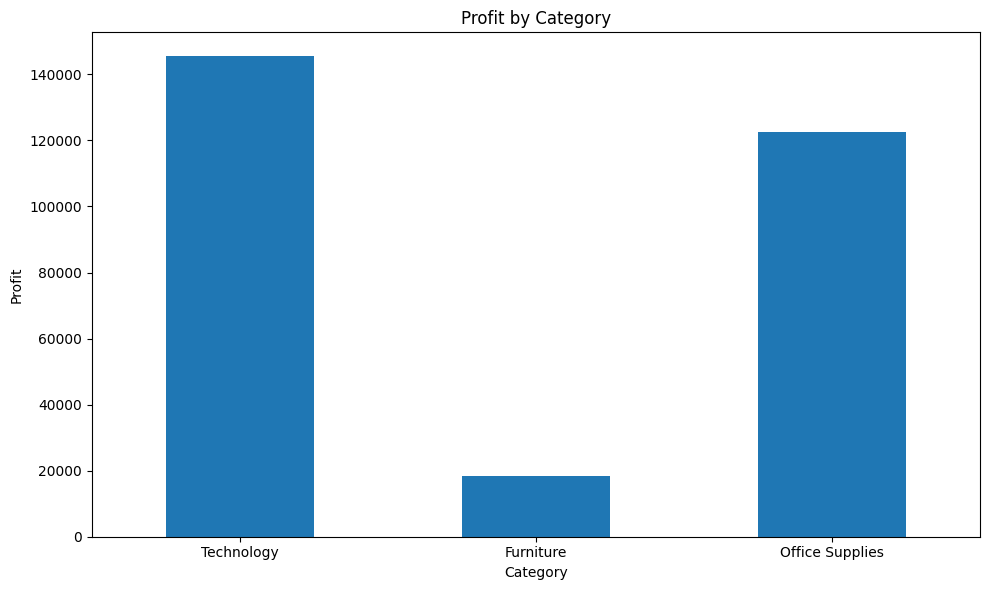

In [8]:
# Chart for Profit
category_summary['Profit'].plot(kind='bar', figsize=(10,6))

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Based on the analysis, evaluating category performance only by sales volume is not fully accurate, as high revenue does not always lead to high profit. In this dataset, the Technology category has both the highest sales and the highest profit, which suggests strong customer demand and high profitability. On the other hand, Furniture ranks second in sales but generates significantly lower profit. This may indicate potential issues with margins, discount levels, shipping costs, or pricing strategy, making this category an important area for further analysis.

# Sub-Category Analysis

**Which sub-categories are the most and least profitable?**

In [9]:
subcategory_profit = df.groupby(['Category','Sub-Category'])[['Sales','Profit']].sum().sort_values(by=['Category','Profit'], ascending=[True,True])
subcategory_profit

Sales      Profit
Category        Sub-Category                         
Furniture       Tables        206965.5320 -17725.4811
                Bookcases     114879.9963  -3472.5560
                Furnishings    91705.1640  13059.1436
                Chairs        328449.1030  26590.1663
Office Supplies Supplies       46673.5380  -1189.0995
                Fasteners       3024.2800    949.5182
                Labels         12486.3120   5546.2540
                Art            27118.7920   6527.7870
                Envelopes      16476.4020   6964.1767
                Appliances    107532.1610  18138.0054
                Storage       223843.6080  21278.8264
                Binders       203412.7330  30221.7633
                Paper          78479.2060  34053.5693
Technology      Machines      189238.6310   3384.7569
                Accessories   167380.3180  41936.6357
                Phones        330007.0540  44515.7306
                Copiers       149528.0300  55617.8249

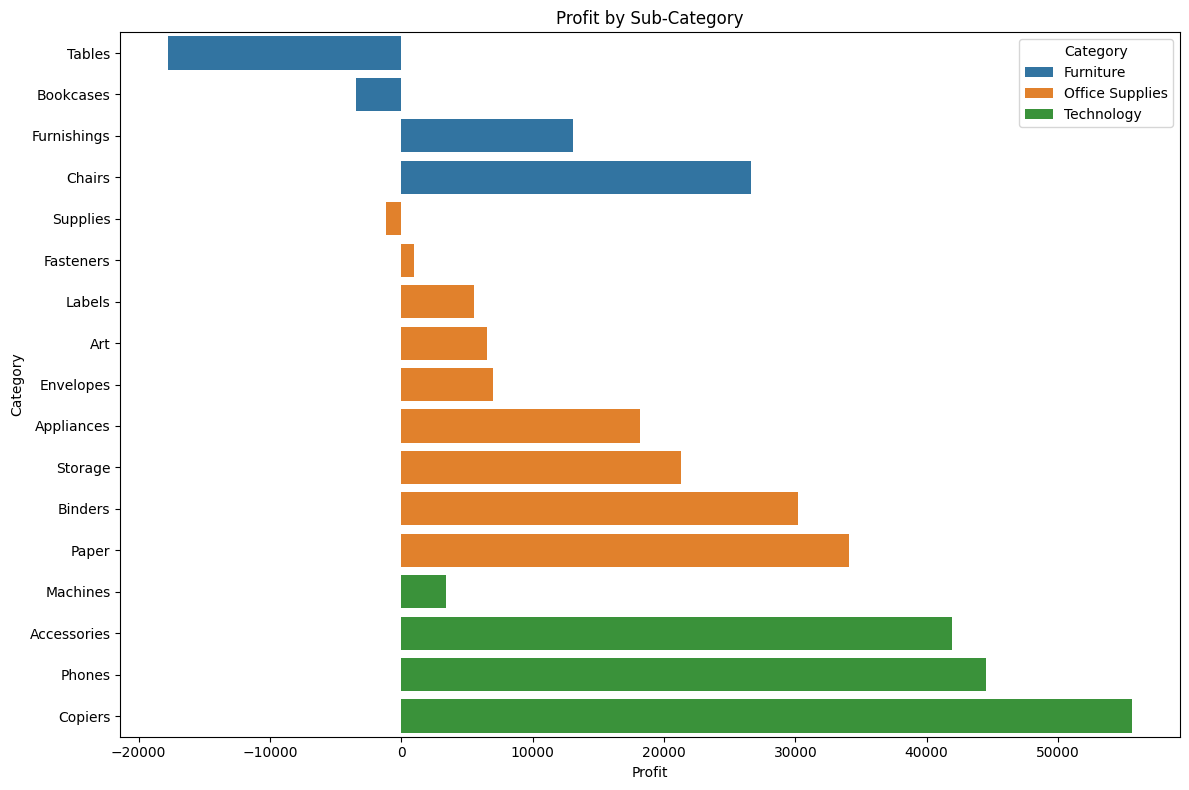

In [10]:
# Chart for sub-categories
subcategory_profit_reset = subcategory_profit.reset_index()

plt.figure(figsize=(12,8))

sns.barplot(
    data=subcategory_profit_reset,
    x='Profit',
    y='Sub-Category',
    hue='Category'
)

plt.title('Profit by Sub-Category')
plt.xlabel('Profit')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

Based on the sub-category analysis, the low profitability of the Furniture category is mainly driven by Tables and Bookcases, both of which generate negative profit. Tables are especially notable: despite having a high sales volume, this sub-category results in a loss. This may indicate potential issues with margins, discount levels, shipping costs, or pricing strategy, making it an important area for further analysis.

At the same time, the Technology category performs strongly due to highly profitable sub-categories such as Copiers, Phones, and Accessories. However, Machines generate significantly lower profit compared to other Technology sub-categories, which may also be worth further investigation.

# Region Analysis

**Which regions perform best?**

In [11]:
region_summary = df.groupby('Region')[['Sales','Profit']].sum().sort_values(by='Sales',ascending=False)
region_summary['Profit Margin (%)'] = region_summary['Profit'] / region_summary['Sales'] * 100
region_summary

,Sales,Profit,Profit Margin (%)
Region,,,
West,725457.8245,108418.4489,14.944831
East,678781.2400,91522.7800,13.483399
Central,501239.8908,39706.3625,7.921629
South,391721.9050,46749.4303,11.934342


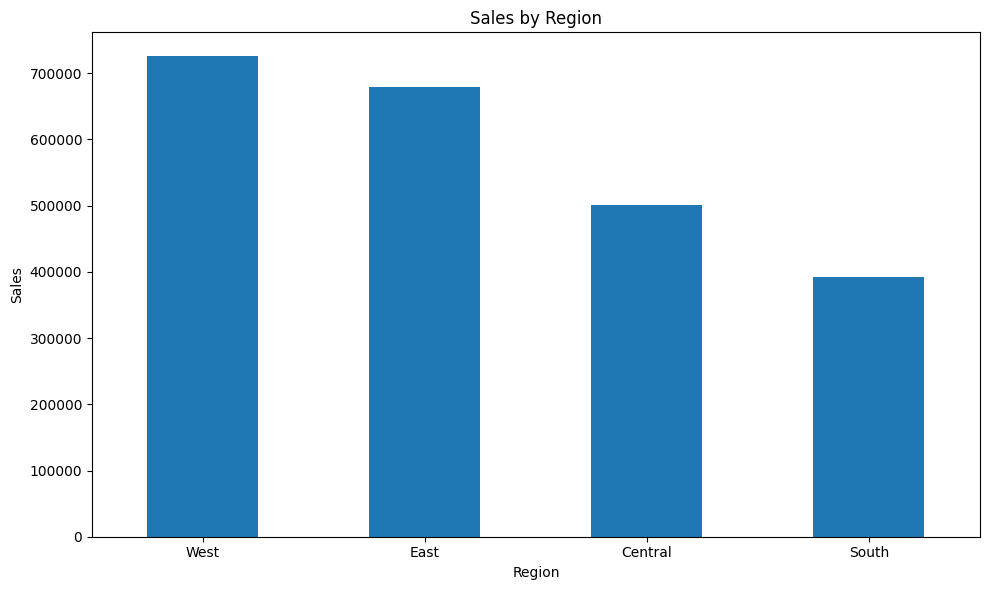

In [12]:
# Chart for Sales
region_summary['Sales'].plot(kind='bar', figsize=(10,6))

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


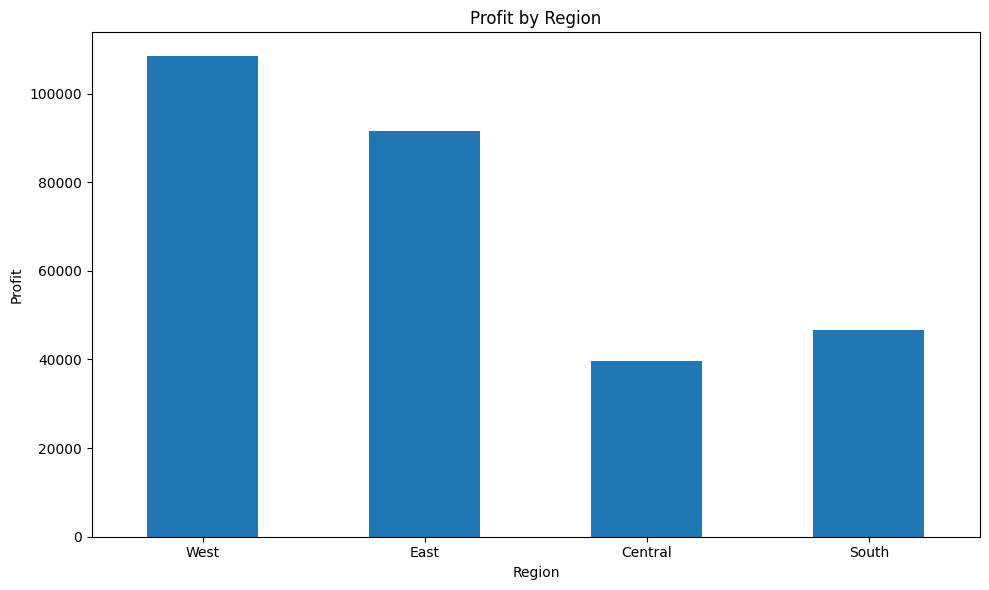

In [13]:
# Chart for Profit

region_summary['Profit'].plot(kind='bar', figsize=(10,6))

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

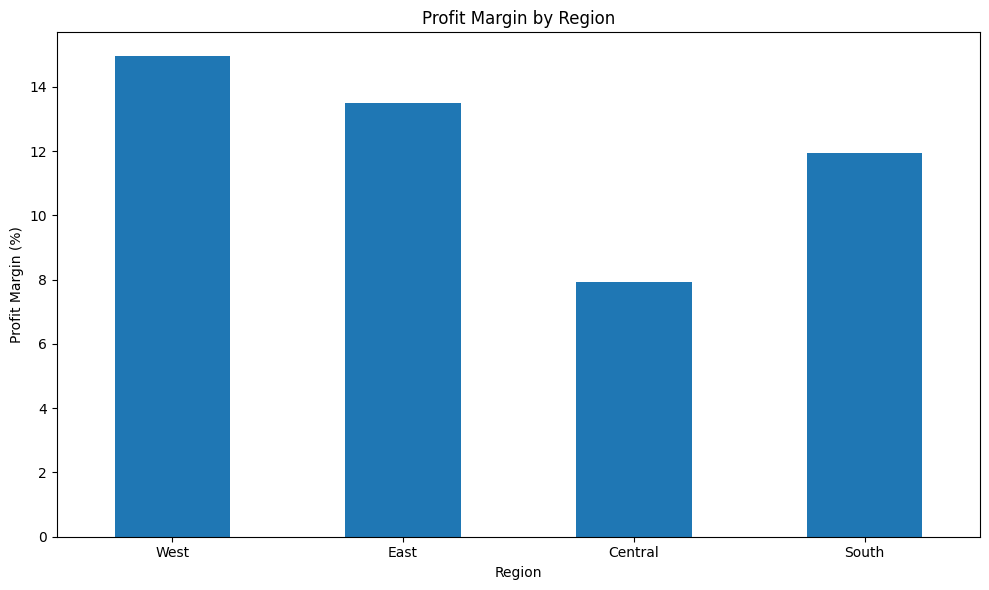

In [14]:
# Chart for Profit Margin

region_summary['Profit Margin (%)'].plot(kind='bar', figsize=(10,6))

plt.title('Profit Margin by Region')
plt.xlabel('Region')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The regional analysis shows that the West region is the strongest performer, with the highest sales, highest profit, and the highest profit margin. East also performs well, generating strong profit and maintaining a relatively high margin.

South has the lowest sales, but its profit margin is higher than Central’s, which suggests that lower sales volume does not necessarily mean weaker business efficiency. Central is the least efficient region, with the lowest profit margin despite having higher sales than South. This may indicate issues related to discount levels, product mix, or lower-margin categories in this region.

# Discount Analysis

**How does discount affect profit?**


In [15]:
discount_summary = df.groupby('Discount').agg(
    Avg_Sales=('Sales', 'mean'),
    Avg_Profit=('Profit', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order ID', 'count')
).sort_index()
discount_summary

,Avg_Sales,Avg_Profit,Total_Profit,Orders
Discount,,,,
0.00,226.742074,66.900292,320987.6032,4798
0.10,578.397351,96.055074,9029.1770,94
0.15,529.971567,27.288298,1418.9915,52
0.20,209.076940,24.702572,90337.3060,3657
0.30,454.742974,-45.679636,-10369.2774,227
0.32,536.794770,-88.560656,-2391.1377,27
0.40,565.134874,-111.927429,-23057.0504,206
0.45,498.634000,-226.646464,-2493.1111,11
0.50,892.705152,-310.703456,-20506.4281,66


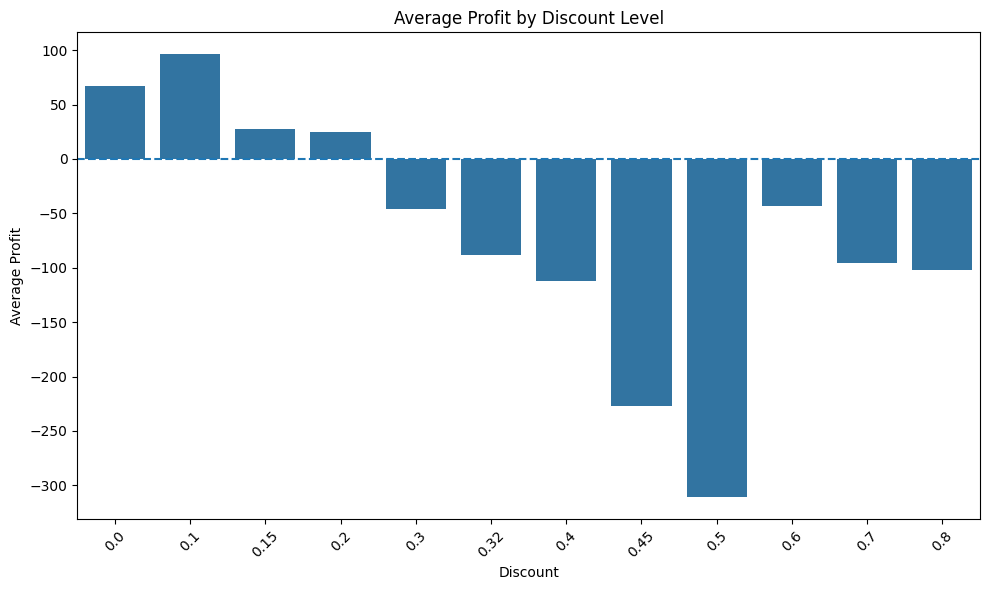

In [16]:
# Chart for average profit
plt.figure(figsize=(10,6))

sns.barplot(
    data=discount_summary.reset_index(),
    x='Discount',
    y='Avg_Profit'
)

plt.axhline(0, linestyle='--')

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

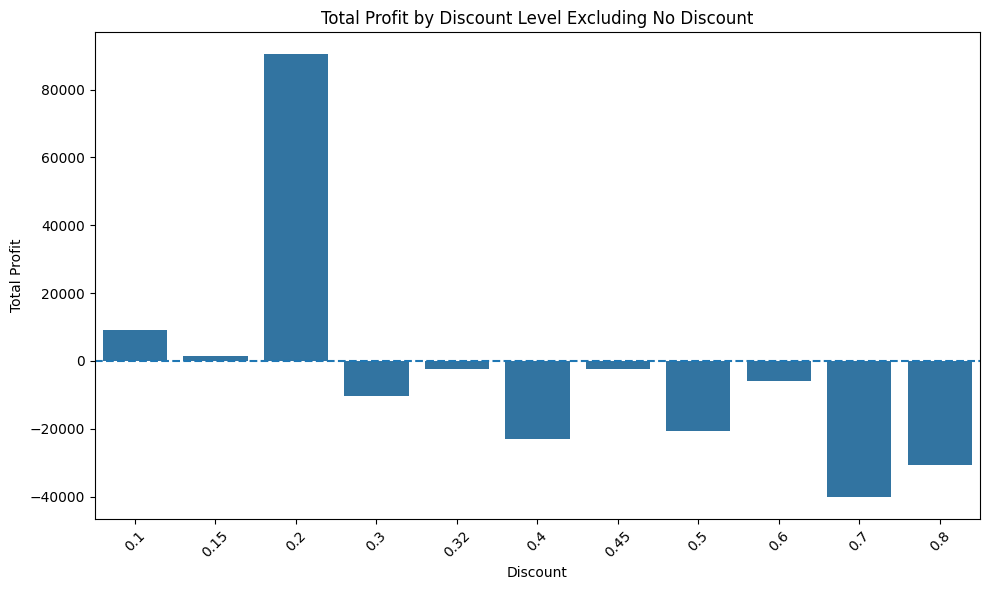

In [17]:
# Chart for total profit
discount_summary_without_zero = discount_summary[discount_summary.index != 0.0]

plt.figure(figsize=(10,6))

sns.barplot(
    data=discount_summary_without_zero.reset_index(),
    x='Discount',
    y='Total_Profit'
)

plt.axhline(0, linestyle='--')

plt.title('Total Profit by Discount Level Excluding No Discount')
plt.xlabel('Discount')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Orders without discounts were excluded from this chart to better visualize the impact of different discount levels on total profit.

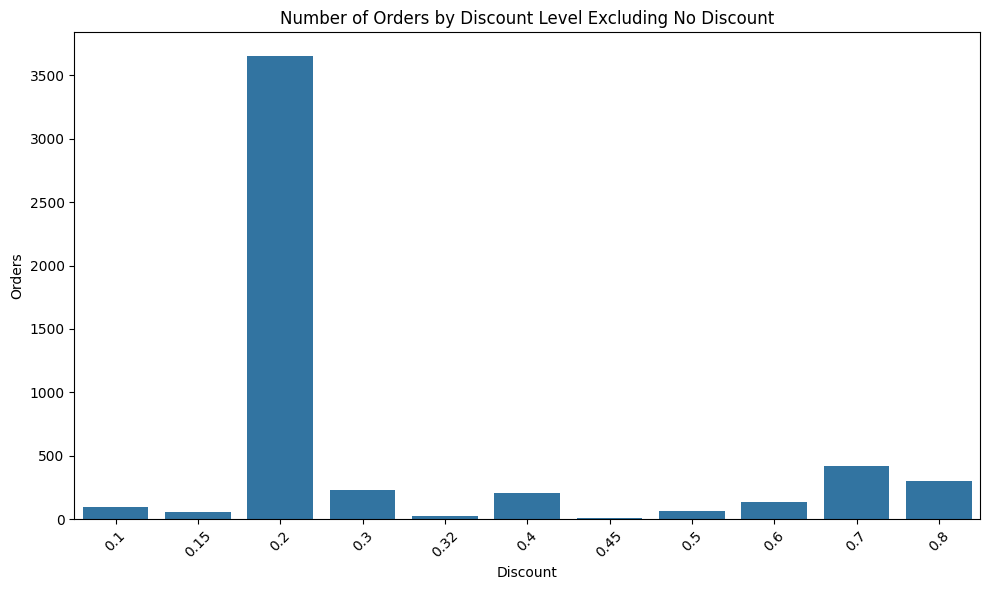

In [18]:
# Chart for orders
discount_summary_without_zero = discount_summary[discount_summary.index != 0.0]

plt.figure(figsize=(10,6))

sns.barplot(
    data=discount_summary_without_zero.reset_index(),
    x='Discount',
    y='Orders'
)

plt.title('Number of Orders by Discount Level Excluding No Discount')
plt.xlabel('Discount')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Orders without discounts were also excluded from this chart to focus specifically on the distribution of discounted orders.

Based on the analysis, the 20% discount appears to be the most effective discount level among discounted orders. It has the highest number of orders among discount levels and also generates the largest positive contribution to total profit. This suggests that a 20% discount may be a relatively sustainable promotional level that supports sales without significantly damaging profitability.

At the same time, discounts above 20% are generally associated with negative profit. Discounts of 70% and 80% are especially important to review, as they continue to be used despite generating losses. This may indicate a need to reconsider the discount strategy for higher discount levels.

It is also important to note that orders without discounts have the highest number of orders and generate the highest total profit overall. Therefore, no-discount orders remain the most profitable scenario in this dataset.

# Sales and Profit Over Time

**How did sales and profit change over time?**

In [19]:
monthly_trends = df.groupby('Order Year-Month')[['Sales','Profit']].sum()
monthly_trends.index = monthly_trends.index.astype(str)

monthly_trends.head()

,Sales,Profit
Order Year-Month,,
2014-01,14236.895,2450.1907
2014-02,4519.892,862.3084
2014-03,55691.009,498.7299
2014-04,28295.345,3488.8352
2014-05,23648.287,2738.7096


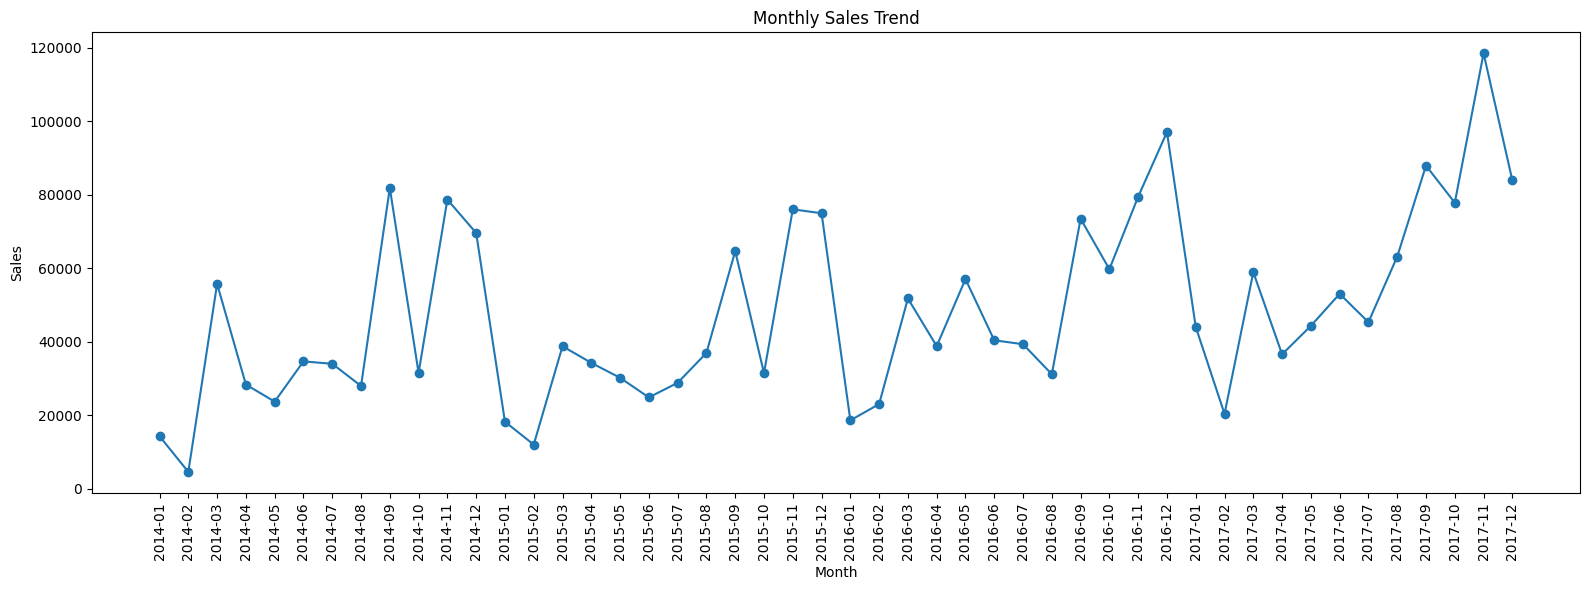

In [20]:
# Chart for monthly sales
plt.figure(figsize=(16,6))

plt.plot(monthly_trends.index,monthly_trends['Sales'], marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [21]:
# Chart for monthly profit

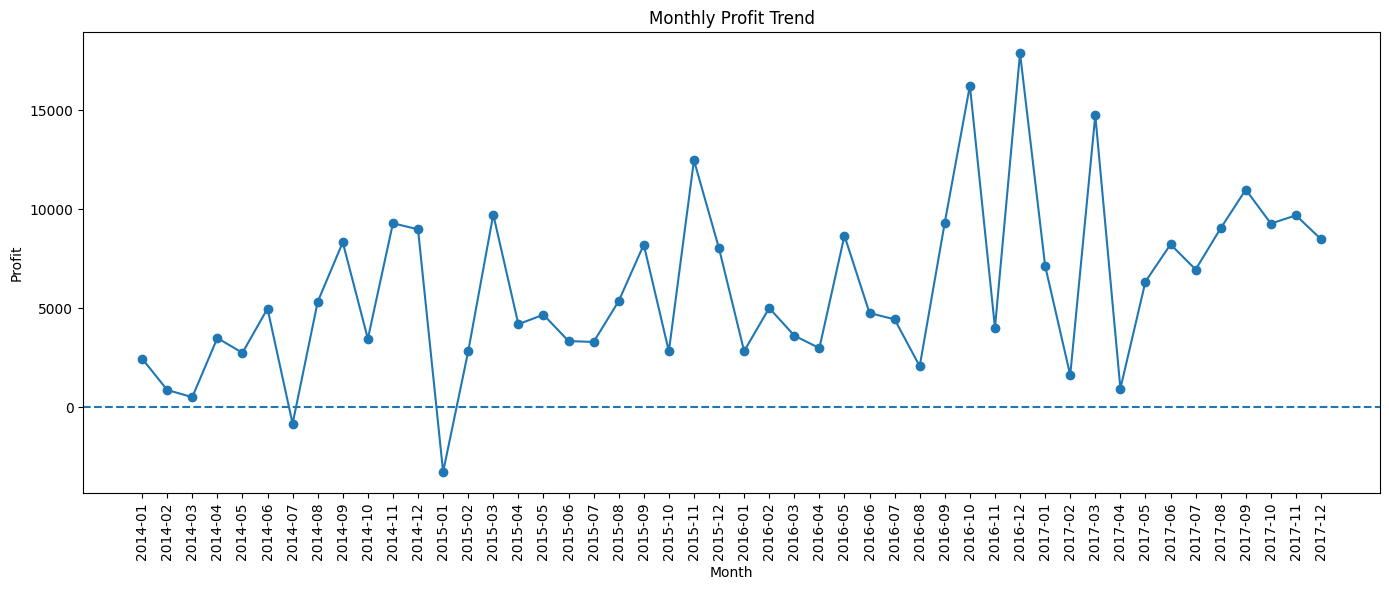

In [22]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_trends.index, monthly_trends['Profit'], marker='o'
)

plt.axhline(0, linestyle='--')

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [23]:
yearly_trends = df.groupby('Order Year')[['Sales', 'Profit']].sum()


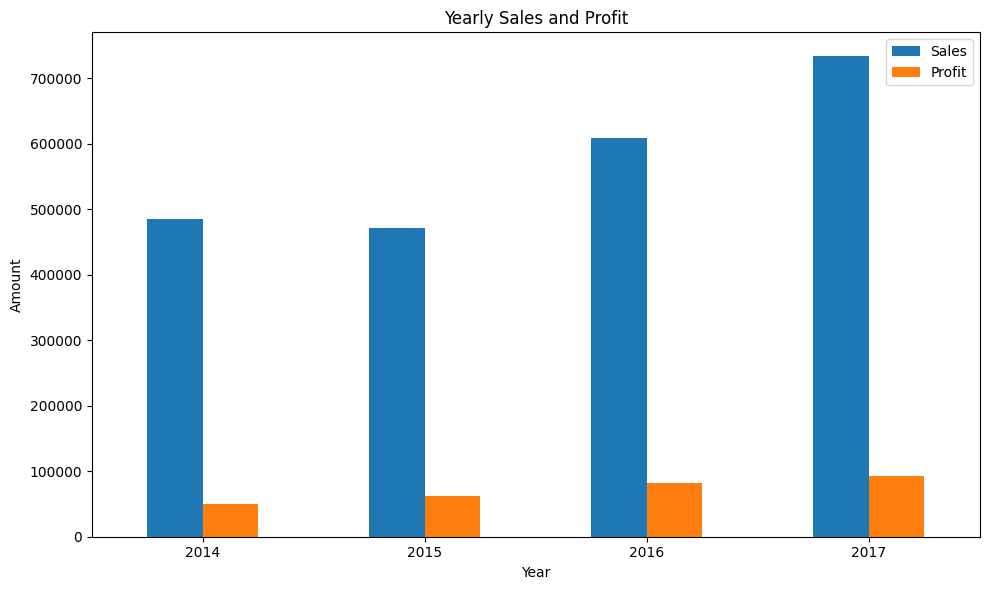

In [24]:
yearly_trends.plot(kind='bar', figsize=(10,6))

plt.title('Yearly Sales and Profit')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The yearly analysis shows that Superstore sales generally increased from 2014 to 2017, with only a slight decline in 2015. At the same time, profit increased every year, including 2015, which indicates positive business development and improving profitability over time.

Monthly trends show that sales often reach higher levels toward the end of the year, especially from September to December. This may be related to seasonal demand and increased shopping activity during the holiday period.

Profit also shows an overall positive trend, but monthly profit is more volatile than sales. Some months show sharp increases, while a few periods even show negative profit. Profit peaks in late 2016 and March 2017 stand out and may require further analysis to understand which categories, regions, or discount levels contributed to these results.

# Conclusion

This analysis shows that Superstore’s business performance should not be evaluated only by sales volume. While sales generally increased from 2014 to 2017, profitability varied significantly across categories, sub-categories, regions, and discount levels.

The Technology category is the strongest performer, generating both the highest sales and the highest profit. In contrast, Furniture has relatively high sales but weak profitability, mainly due to unprofitable sub-categories such as Tables and Bookcases.

Regional analysis shows that the West region performs best overall, with the highest sales, profit, and profit margin. The Central region is the least efficient, despite having higher sales than the South region, which may suggest potential issues with discounts, product mix, or lower-margin categories.

Discount analysis indicates that orders without discounts generate the highest total profit overall. Among discounted orders, the 20% discount level appears to be the most effective, combining a high number of orders with positive total profit. However, discounts above 20% are generally associated with lower or negative profitability.

Finally, yearly trends show positive business growth over time, while monthly trends reveal seasonal peaks and more volatile profit patterns.

# Key Findings

- Technology is the most profitable category.
- Furniture has high sales but relatively low profitability.
- Tables and Bookcases are the main loss-making sub-categories.
- West is the strongest region by sales, profit, and profit margin.
- Central has the lowest profit margin among regions.
- Orders without discounts generate the highest total profit overall.
- Among discounted orders, the 20% discount level performs best.
- Discounts above 20% are generally associated with negative profitability.
- Sales and profit increased overall from 2014 to 2017.


# Recommendations

- Review the Furniture category, especially Tables and Bookcases, to understand why these sub-categories generate losses.
- Reconsider high discount levels above 20%, as they are generally associated with negative profitability.
- Use the 20% discount level more strategically, as it appears to be the most effective discount among discounted orders.
- Investigate the Central region to identify whether low profitability is caused by discounts, product mix, or specific sub-categories.
- Continue investing in strong Technology sub-categories such as Copiers, Phones, and Accessories.
- Analyze high-performing months in more detail to understand what drives seasonal sales and profit peaks.

# Limitations

This analysis is based only on the available Superstore dataset. Some important business factors such as marketing costs, inventory levels, customer acquisition costs, detailed shipping costs, and product-level margins are not included. Therefore, some recommendations should be treated as hypotheses for further investigation.